# Prapemrosesan Data Teks dan Ekstraksi TF-IDF

Model algoritma tidak dapat memproses teks mentah secara langsung, sehingga teks harus dikonversi menjadi representasi angka[cite: 1]. Sebelum diekstrak, data teks harus dibersihkan dari derau (*noise*).

Langkah prapemrosesan meliputi:
* **Cleansing & Case Folding:** Menghapus simbol/angka dan mengubah teks menjadi huruf kecil.
* **Stopword Removal & Stemming:** Membuang kata hubung umum yang tidak informatif dan mengembalikan kata ke bentuk dasarnya.

In [2]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# 1. Memuat Dataset
df = pd.read_csv('data_berita_sport_finance.csv')
# Menggabungkan fitur judul dan isi untuk konteks yang lebih kaya
df['Teks Mentah'] = df['Judul Berita'] + " " + df['Isi Berita']

# 2. Inisialisasi NLP Tools
stop_words_id = set(stopwords.words('indonesian'))
stop_words_en = set(stopwords.words('english'))
stop_words_final = stop_words_id.union(stop_words_en)
# Tambahan daftar kata penghubung dan singkatan yang sering muncul di berita
custom_stopwords = {
    'dan','atau','yang','dengan','juga','karena','namun','sehingga','adalah','akan',
    'saat','pada','untuk','dari','oleh','dalam','dapat','kami','mereka','kita','saya',
    'ini','itu','tersebut','tsb','dll','dkk','spt','yg','dgn','dr','jr','sr','thn',
    'tdk','gak','nggak','ya','ia','mereka','terkait','berdasarkan','setelah','sebelum',
    'sambil','selain','sekitar','hingga','maupun','bisa','per','waktu','apakah','adanya'
}
stop_words_final = stop_words_final.union(custom_stopwords)
stemmer = StemmerFactory().create_stemmer()

def bersihkan_teks(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^a-zA-Z\s]', ' ', text).lower()
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [w for w in words if w not in stop_words_final and len(w) > 1]
    # Menerapkan stemming dan menghapus stopword
    processed_words = [stemmer.stem(w) for w in words]
    return ' '.join(processed_words)

print("Memproses pembersihan teks (estimasi waktu: 2-4 menit)...")
df['Teks Bersih'] = df['Teks Mentah'].apply(bersihkan_teks)
display(df[['Label Kategori', 'Teks Bersih']].head())

Memproses pembersihan teks (estimasi waktu: 2-4 menit)...


,Label Kategori,Teks Bersih
0,SPORT,banjir asi games jepang aman kota nagoya jepan...
1,SPORT,debut asi games ubed sabar rebut emas regu put...
2,SPORT,men world tennis championship rifqi rafalentin...
3,SPORT,kevin sanjaya antusias lihat semangat talenta ...
4,SPORT,atlet muda modern pentathlon sempat karier mil...


## Ekstraksi Fitur: TF-IDF (Term Frequency - Inverse Document Frequency)

Metode representasi *Bag-of-Words* (BOW) memiliki kelemahan karena didominasi oleh kata-kata umum dan sering memicu *sparsity* (matriks jarang berisikan banyak nilai nol)[cite: 1]. 

TF-IDF mengatasi hal ini menggunakan formula $tf(t, d) \times idf(t, D)$, di mana $idf(t) = log(N / df(t))$[cite: 1]. Mekanisme ini secara otomatis memberikan penalti (skor rendah) pada kata umum yang muncul di seluruh dokumen, dan menyoroti kata kunci unik yang mencirikan dokumen tertentu[cite: 1].

In [3]:
import os
from sklearn.feature_extraction.text import TfidfVectorizer

print("Mengekstrak fitur TF-IDF...")
# Membangun Document-Term Matrix (DTM)
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['Teks Bersih'])

# Konversi ke DataFrame
fitur_kata = vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=fitur_kata)
df_tfidf.insert(0, 'Label Kategori', df['Label Kategori'])

# Ekspor ke folder kerja aktif agar file selalu muncul di lokasi project
output_path = os.path.join(os.getcwd(), 'tfidf_berita.csv')
df_tfidf.to_csv(output_path, index=False)
print(f"Bentuk Matriks TF-IDF: {df_tfidf.shape[0]} baris x {df_tfidf.shape[1]} kolom kata unik.")
display(df_tfidf.head())

Mengekstrak fitur TF-IDF...
Bentuk Matriks TF-IDF: 200 baris x 4884 kolom kata unik.


,Label Kategori,aadi,aam,aan,aau,abadi,abai,abdi,abdul,abdullah,...,zapp,zein,zeinatma,zenix,zhang,zigmars,zona,zulfikar,zulfikri,zulhas
0,SPORT,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,SPORT,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SPORT,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SPORT,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SPORT,0.0,0.0,0.0,0.038753,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Visualisasi TF-IDF: Kata Unik per Kelas

Setelah matriks TF-IDF terbentuk, kita menghitung total bobot setiap kata dalam tiap kelas berita. Langkah ini membantu melihat kata-kata yang paling dominan dan paling khas untuk klasifikasi:

- **SPORT** biasanya akan menonjol pada istilah cabang olahraga, atlet, turnamen, dan momentum pertandingan.
- **FINANCE** biasanya akan menonjol pada istilah pasar, saham, ekonomi, investasi, dan kebijakan keuangan.
- Grafik batang dan word cloud ini memudahkan kita membandingkan kata kunci yang paling relevan di masing-masing kategori.

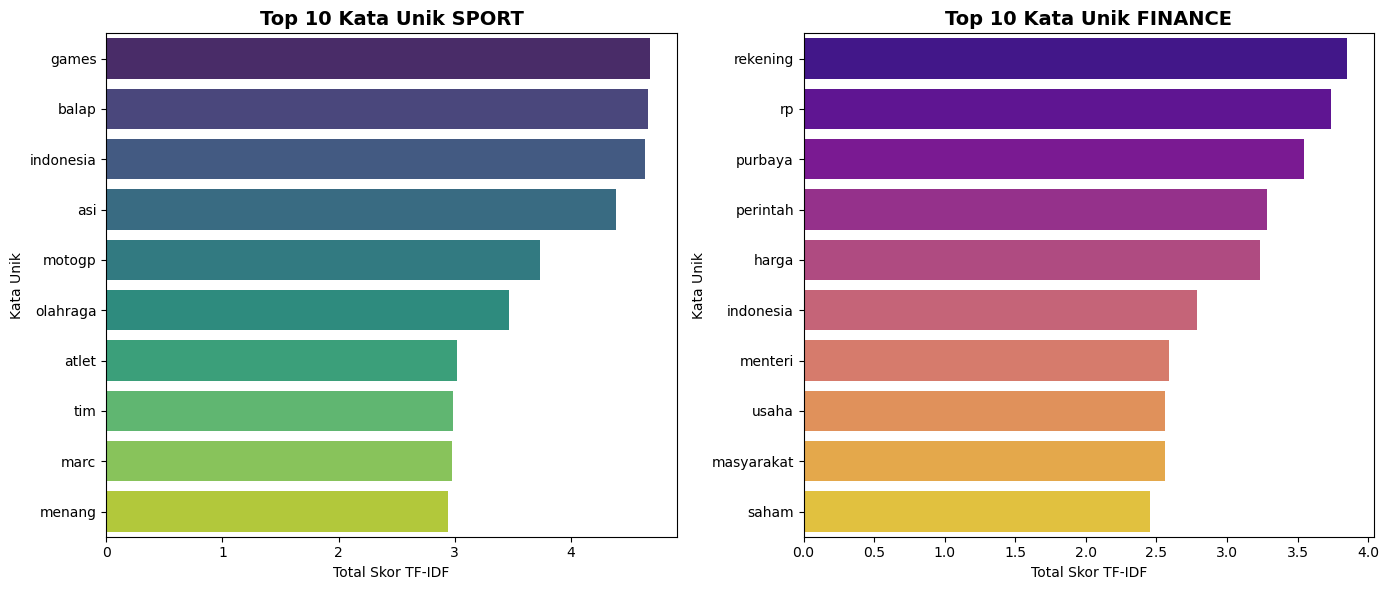

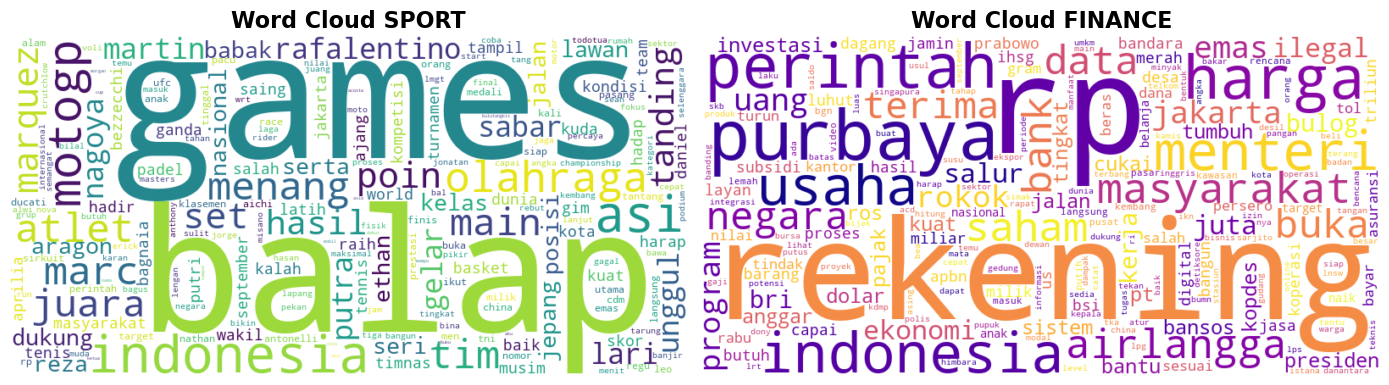

Top 10 SPORT:
games        4.675968
balap        4.665471
indonesia    4.634424
asi          4.383941
motogp       3.733424
olahraga     3.462562
atlet        3.019805
tim          2.981683
marc         2.974593
menang       2.942188
dtype: float64

Top 10 FINANCE:
rekening      3.851239
rp            3.740563
purbaya       3.548182
perintah      3.285501
harga         3.237315
indonesia     2.788878
menteri       2.588415
usaha         2.562751
masyarakat    2.560089
saham         2.456732
dtype: float64


In [ ]:
import warnings

warnings.filterwarnings('ignore', category=ResourceWarning)
warnings.filterwarnings('ignore', message='.*unclosed file.*wordcloud.*stopwords.*')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

# Siapkan data setiap kelas secara terpisah
sport_df = df[df['Label Kategori'] == 'SPORT'].copy()
finance_df = df[df['Label Kategori'] == 'FINANCE'].copy()

# 1. Inisialisasi dan Transformasi TF-IDF untuk masing-masing kelas
vectorizer_sport = TfidfVectorizer()
vectorizer_finance = TfidfVectorizer()

sport_matrix = vectorizer_sport.fit_transform(sport_df['Teks Bersih'])
finance_matrix = vectorizer_finance.fit_transform(finance_df['Teks Bersih'])

sport_fitur = vectorizer_sport.get_feature_names_out()
finance_fitur = vectorizer_finance.get_feature_names_out()

sport_df_tfidf = pd.DataFrame(sport_matrix.toarray(), columns=sport_fitur)
finance_df_tfidf = pd.DataFrame(finance_matrix.toarray(), columns=finance_fitur)

# Hitung total bobot TF-IDF per kata untuk tiap kelas
sport_skor = sport_df_tfidf.sum().sort_values(ascending=False)
finance_skor = finance_df_tfidf.sum().sort_values(ascending=False)

# VISUALISASI 1: Bar Chart (Top 10 Kata per Kelas)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(ax=axes[0], x=sport_skor.head(10).values, y=sport_skor.head(10).index, palette='viridis')
axes[0].set_title('Top 10 Kata Unik SPORT', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Skor TF-IDF')
axes[0].set_ylabel('Kata Unik')

sns.barplot(ax=axes[1], x=finance_skor.head(10).values, y=finance_skor.head(10).index, palette='plasma')
axes[1].set_title('Top 10 Kata Unik FINANCE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Skor TF-IDF')
axes[1].set_ylabel('Kata Unik')

plt.tight_layout()
plt.show()

# VISUALISASI 2: Word Cloud per Kelas
wordcloud_sport = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate_from_frequencies(dict(zip(sport_skor.index, sport_skor.values)))
wordcloud_finance = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate_from_frequencies(dict(zip(finance_skor.index, finance_skor.values)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(wordcloud_sport, interpolation='bilinear')
axes[0].set_title('Word Cloud SPORT', fontsize=16, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(wordcloud_finance, interpolation='bilinear')
axes[1].set_title('Word Cloud FINANCE', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print('Top 10 SPORT:')
print(sport_skor.head(10))
print('\nTop 10 FINANCE:')
print(finance_skor.head(10))

## Reduksi Dimensi: Principal Component Analysis (PCA)

Ekstraksi TF-IDF menghasilkan ribuan dimensi (kolom) yang berisiko memicu *Curse of Dimensionality*, di mana ruang fitur yang bertambah eksplosif membebankan komputasi algoritma pemelajaran mesin[cite: 1]. 

Dengan menerapkan PCA (yang secara fundamental sejalan dengan metode reduksi matriks SVD), kita memampatkan matriks jarang (*sparse*) menjadi matriks padat (*dense*) berdimensi rendah, sekaligus mempertahankan pola informasi utama[cite: 1].

In [5]:
from sklearn.decomposition import PCA

# Memisahkan target label dari fitur numerik
X_tfidf = df_tfidf.drop('Label Kategori', axis=1)

# Mereduksi matriks menjadi 50 komponen utama
n_komponen = 50
pca = PCA(n_components=n_komponen)
pca_matrix = pca.fit_transform(X_tfidf)

# Format ulang ke DataFrame
kolom_pca = [f'PC{i+1}' for i in range(n_komponen)]
df_pca = pd.DataFrame(pca_matrix, columns=kolom_pca)
df_pca.insert(0, 'Label Kategori', df['Label Kategori'])

# Ekspor
df_pca.to_csv('pca_berita.csv', index=False)
print(f"Bentuk Matriks PCA: {df_pca.shape[0]} baris x {df_pca.shape[1]} komponen utama.")
display(df_pca.head())

Bentuk Matriks PCA: 200 baris x 51 komponen utama.


,Label Kategori,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
0,SPORT,-0.002336,0.378591,-0.192355,0.061930,0.053859,0.074792,0.017405,0.000319,-0.040042,...,-0.075919,0.058082,-0.041233,0.085906,0.018591,-0.088471,0.070995,0.033440,0.013710,0.038654
1,SPORT,-0.081886,0.330859,-0.073224,0.088307,0.062741,0.104325,-0.064172,0.167255,-0.055915,...,-0.030056,0.015502,-0.034773,0.016818,0.059983,-0.018370,-0.007640,-0.015642,0.036046,-0.029633
2,SPORT,-0.225481,0.080880,0.522169,0.204083,0.029647,0.064413,0.056673,-0.153121,-0.017215,...,0.038161,-0.019840,0.028938,0.057969,0.003934,-0.009487,-0.008773,-0.010378,0.046581,0.049721
3,SPORT,-0.013706,0.068602,-0.000187,-0.016075,-0.045793,-0.092166,0.036761,0.003022,0.076916,...,0.133031,-0.065142,0.010254,0.069223,-0.036667,-0.015460,0.177696,-0.024146,-0.010615,-0.192625
4,SPORT,-0.011071,0.150544,-0.058226,-0.010365,-0.038549,-0.119927,0.052920,-0.034091,0.138053,...,0.012426,0.059782,0.020596,0.012374,-0.038096,0.029024,-0.027990,0.030128,0.018565,-0.028225


## Visualisasi PCA: Persebaran Data Berita

Setelah fitur TF-IDF direduksi menjadi beberapa komponen utama, kita memplot dua komponen utama pertama (PC1 dan PC2) agar pola distribusi data terlihat secara visual. Dengan PCA, data yang awalnya berdimensi tinggi dapat dilihat dalam ruang dua dimensi, sehingga kita dapat menilai apakah data SPORT dan FINANCE membentuk kelompok yang berbeda.

- Jika titik-titik dari dua kelas terpisah dengan jelas, maka fitur yang dihasilkan cukup kuat membedakan kategori berita.
- Semakin jauh jarak antar kelompok, semakin baik model dapat membedakan kelas berdasarkan kata kunci di teks.

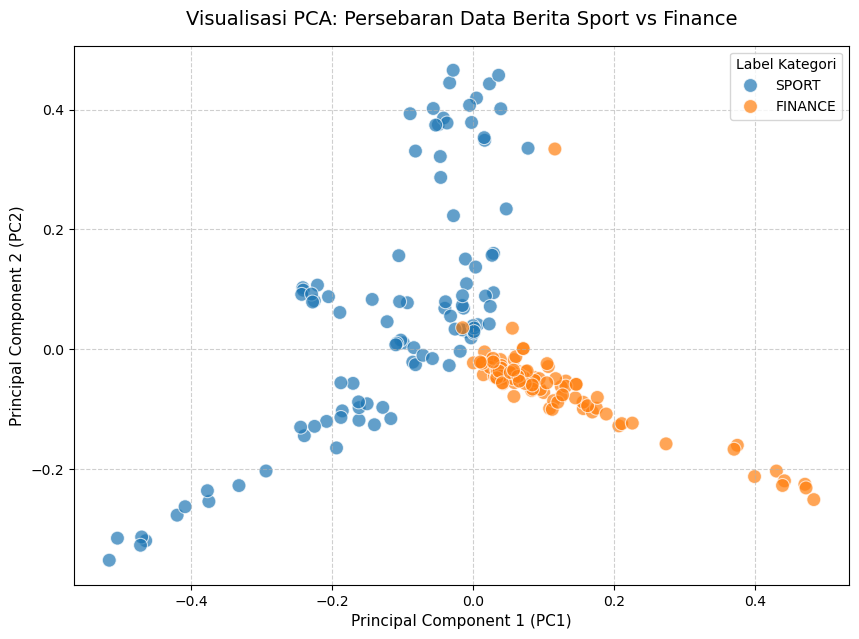

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur ukuran kanvas grafik
plt.figure(figsize=(10, 7))

# Memplot dua komponen utama pertama (PC1 sebagai sumbu X, PC2 sebagai sumbu Y)
sns.scatterplot(
    data=df_pca, 
    x='PC1', 
    y='PC2', 
    hue='Label Kategori', 
    palette=['#1f77b4', '#ff7f0e'], # Biru untuk Sport, Oranye untuk Finance
    s=100, # Ukuran titik
    alpha=0.7 # Transparansi agar titik yang bertumpuk terlihat
)

# Menambahkan judul dan label sumbu
plt.title('Visualisasi PCA: Persebaran Data Berita Sport vs Finance', fontsize=14, pad=15)
plt.xlabel('Principal Component 1 (PC1)', fontsize=11)
plt.ylabel('Principal Component 2 (PC2)', fontsize=11)

# Menambahkan garis bantu (grid)
plt.grid(True, linestyle='--', alpha=0.6)

# Merender dan menampilkan grafik ke layar
plt.show()